## Model Training

#### 1. Import Data and Required Packages
##### Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline
### for modelling
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')


In [2]:
df=pd.read_csv('data/stud.csv')

In [3]:
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


### selecting maths score as depenedent feature

dividing independent and dependent features

In [4]:
X = df.drop(columns='math_score')
y=df['math_score']

In [5]:
df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='object')

In [6]:
cols=['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course']

for col in cols:
    print(f"Categories in {col}: {df[col].unique()}")

Categories in gender: ['female' 'male']
Categories in race_ethnicity: ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in parental_level_of_education: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in lunch: ['standard' 'free/reduced']
Categories in test_preparation_course: ['none' 'completed']


In [7]:
### numeric and catagorical features in X
numeric_features=[feature for feature in X.columns if df[feature].dtype!='O']
catagorical_features=[feature for feature in X.columns if df[feature].dtype=='O']

print(f"we have {len(numeric_features)} numeric features : {numeric_features}")
print(f"we have {len(catagorical_features)} catagorical features : {catagorical_features}")

we have 2 numeric features : ['reading_score', 'writing_score']
we have 5 catagorical features : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [15]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

oh_encoder = OneHotEncoder() ### as all the features are catagorical 
num_encoder= StandardScaler()
preprocessor = ColumnTransformer(
    [('OneHotEncoder',oh_encoder,catagorical_features),
     ('StanderdScaler',num_encoder,numeric_features)],

    )



In [16]:
X_encoded = preprocessor.fit_transform(X)

In [17]:
X_encoded.shape

(1000, 19)

#### separating dataset in training and testing set

In [18]:
from sklearn.model_selection import train_test_split 
X_train,X_test,y_train,y_test=train_test_split(X_encoded,y,test_size=0.2,random_state=42)


In [19]:
X_train.shape, X_test.shape

((800, 19), (200, 19))

#### Create an Evaluate Function to give all metrics after model Training

In [20]:
def evaluate(y_test,y_pred):
    mae=mean_absolute_error(y_test,y_pred)
    mse=mean_squared_error(y_test,y_pred)
    rmse=np.sqrt(mean_squared_error(y_test,y_pred))
    r2=r2_score(y_test,y_pred)
    return mae , mse, rmse,r2


In [21]:
models= {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}
model_list = []
r2_list = []

for i, (name, model) in enumerate(models.items()):


    ## training the data
    model.fit(X_train, y_train)


    y_train_pred=model.predict(X_train) ## predicting 
    y_test_pred=model.predict(X_test)

    ### Evaluation 
    model_train_mae ,model_train_mse, model_train_rmse, model_train_r2 = evaluate(y_train, y_train_pred)
    model_test_mae ,model_test_mse, model_test_rmse, model_test_r2 = evaluate(y_test, y_test_pred)


    print(name)
    model_list.append(name)
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')



Linear Regression
Model performance for Training set
- Root Mean Squared Error: 5.3402
- Mean Absolute Error: 4.2723
- R2 Score: 0.8735
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.4214
- Mean Absolute Error: 4.2253
- R2 Score: 0.8792


Lasso
Model performance for Training set
- Root Mean Squared Error: 6.5938
- Mean Absolute Error: 5.2063
- R2 Score: 0.8071
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 6.5197
- Mean Absolute Error: 5.1579
- R2 Score: 0.8253


Ridge
Model performance for Training set
- Root Mean Squared Error: 5.3233
- Mean Absolute Error: 4.2650
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3904
- Mean Absolute Error: 4.2111
- R2 Score: 0.8806


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 5.7077
- Mean Absolute Error: 4.5167
- R2 Score: 0.8555
-----------------------

Among all models, Ridge Regression performed best with an R2 score of ~=0.88 on the test set. Linear Regression also gave very similar results, indicating that the dataset has a strong linear relationship. Tree based models like Decision Tree badly overfit, while ensemble methods like Random Forest and boosting models performed well but did not outperform simpler linear models. Therefore, Ridge Regression was selected as the final model due to its balance of performance and generalization.

### Ridge rigression

In [23]:
from sklearn.model_selection import GridSearchCV

ridge=Ridge()

params = {'alpha':[0.01,0.1,1,10,100]}

grid= GridSearchCV(estimator=ridge,param_grid=params,
                   scoring='r2',cv=5)

grid.fit(X_train,y_train)

print("Best alpha:",grid.best_params_)
print("Best score:",grid.best_score_)

Best alpha: {'alpha': 1}
Best score: 0.8686068301347675


In [24]:
ridge=Ridge(alpha=1)
ridge.fit(X_train,y_train)

y_pred=ridge.predict(X_test)


Plotting y_test,y_pred

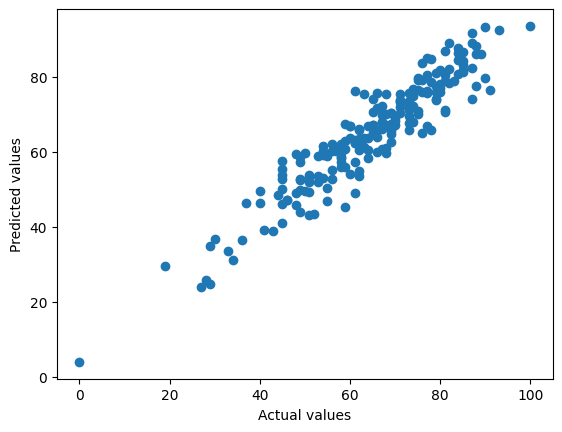

In [26]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.show()

<Axes: xlabel='math_score'>

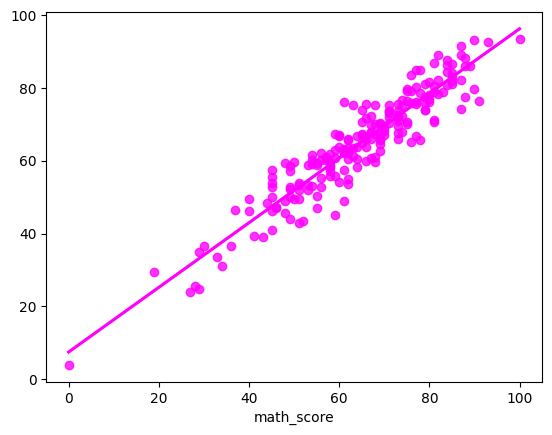

In [27]:
sns.regplot(x=y_test,y=y_pred,ci=None,color='magenta')

#### Difference between Actual and Predicted Values

In [29]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.398705,14.601295
737,53,58.842469,-5.842469
740,80,76.992129,3.007871
660,74,76.805898,-2.805898
411,84,87.615387,-3.615387
...,...,...,...
408,52,43.492293,8.507707
332,62,62.170763,-0.170763
208,74,67.910325,6.089675
613,65,67.061504,-2.061504
